# Contexto, Objetivo e Hipóteses

# Carregamento de Dados e Entendimento Inicial

* Carregando as bibliotecas

In [10]:
# ============================================================
# Reprodutibilidade global (SEEDS)
# ============================================================

import os
import random
import numpy as np

SEED = 42

# Garante determinismo em hashing interno do Python
os.environ["PYTHONHASHSEED"] = str(SEED)

# Seeds globais
random.seed(SEED)
np.random.seed(SEED)

# ============================================================
# 1. Padrão e Visualização
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import shap 
from datetime import datetime

warnings.filterwarnings("ignore")
# Para visualização do SHAP no notebook


# ============================================================
# 2. Estatística e Matemática
# ============================================================
from scipy import stats
from scipy.stats import chi2_contingency

# ============================================================
# 3. Pré-processamento e Transformação
# ============================================================
import unicodedata
import re
from sklearn.preprocessing import (
    OneHotEncoder, 
    StandardScaler,
)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from tempfile import mkdtemp

# ============================================================
# 4. Modelagem e Seleção
# ============================================================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# ============================================================
# 5. Algoritmos de Classificação
# ============================================================
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ============================================================
# 6. Métricas de Avaliação
# ============================================================
from sklearn.metrics import (
    f1_score,
    precision_score,
    average_precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    brier_score_loss,
    precision_recall_curve,
)

from sklearn.calibration import calibration_curve

# ============================================================
# 7. Produção/Exportação
# ============================================================
import joblib

from joblib import Memory
cachedir = "./cache_preprocess"
memory = Memory(location=cachedir, verbose=0)

from pathlib import Path

In [11]:
df = pd.read_csv(r'Data/Telco_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


* Legenda de classe

* Entendimento inical

In [12]:
rows, columns = df.shape
print(f"Registros: {rows}")
print(f"Features: {columns}")

Registros: 7043
Features: 21


In [13]:
# Há incosistência e erros em TotalCharges e seu tipo deveria ser float.
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [14]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [15]:
print("Dados faltantes por coluna:")
print("-"*80)
df.isna().sum()/len(df)

Dados faltantes por coluna:
--------------------------------------------------------------------------------


customerID          0.000000
gender              0.000000
SeniorCitizen       0.000000
Partner             0.000000
Dependents          0.000000
tenure              0.000000
PhoneService        0.000000
MultipleLines       0.000000
InternetService     0.000000
OnlineSecurity      0.000000
OnlineBackup        0.000000
DeviceProtection    0.000000
TechSupport         0.000000
StreamingTV         0.000000
StreamingMovies     0.000000
Contract            0.000000
PaperlessBilling    0.000000
PaymentMethod       0.000000
MonthlyCharges      0.000000
TotalCharges        0.001562
Churn               0.000000
dtype: float64

In [16]:
print(f"Valores faltantes: {df.duplicated().sum()}")

Valores faltantes: 0


In [17]:
print("⚠️ Aviso: Dataset apresenta target desbalanceada")
print("-"*50)
df["Churn"].value_counts(normalize=True)*100

⚠️ Aviso: Dataset apresenta target desbalanceada
--------------------------------------------------


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

* Identificação de potenciais problemas

# Análise Exploratória

* Dataset EDA

In [18]:
df_eda = df.copy()

* Transformações no dataset

In [19]:
map1 = {"Male":0, "Female":1}
map2 = {"Yes":1, "No":0}

df_eda['gender'] = df['gender'].map(map1)

cols_map = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]

for col in cols_map:
    df_eda[col] = df_eda[col].map(map2)

* Descrição do dataset temporário

In [20]:
df_eda[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


* Classificação das variáveis

In [21]:
target = 'Churn'

cols_num = ['tenure', 'MonthlyCharges', 'TotalCharges']

cols_bin = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

cols_cat = ['MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 
            'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 
            'Contract', 'PaymentMethod']

* Distribuição da variável target

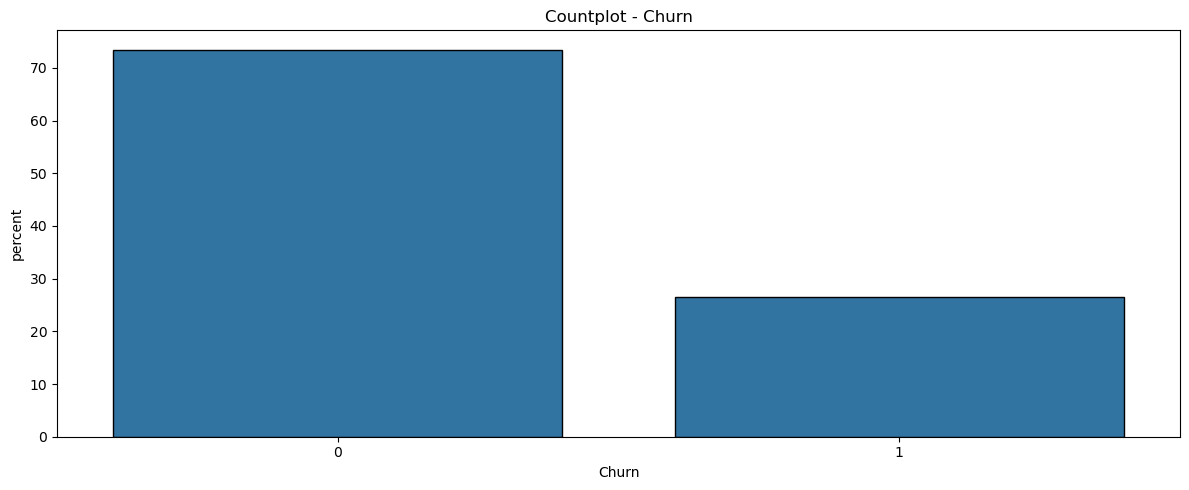

In [22]:
plt.figure(figsize=(12,5))

sns.countplot(data=df_eda, x=target, stat="percent", edgecolor="black")

plt.title(f"Countplot - {target}")
plt.tight_layout()
plt.show()

* Distribuição das variáveis numéricas

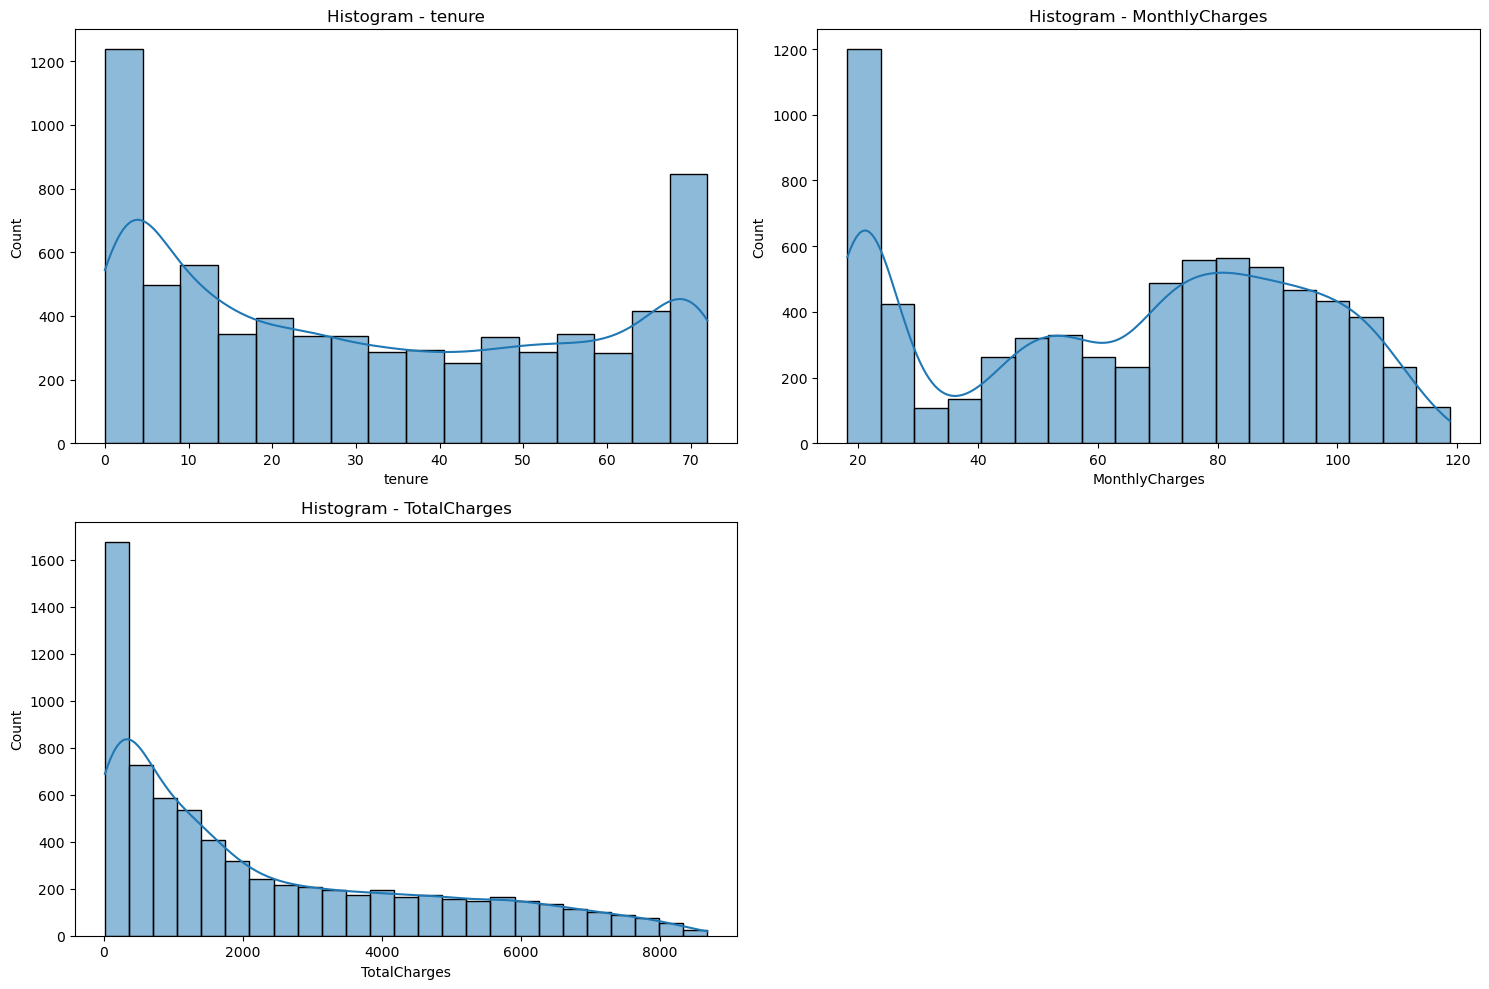

In [23]:
fig, axes = plt.subplots(2, 2, figsize = (15,10))
axes = axes.flatten()

for ax, col in zip(axes,cols_num):
    sns.histplot(data=df_eda, x=col, kde=True, edgecolor="black",ax=ax)
    ax.set_title(f"Histogram - {col}")

for ax in axes[len(cols_num):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

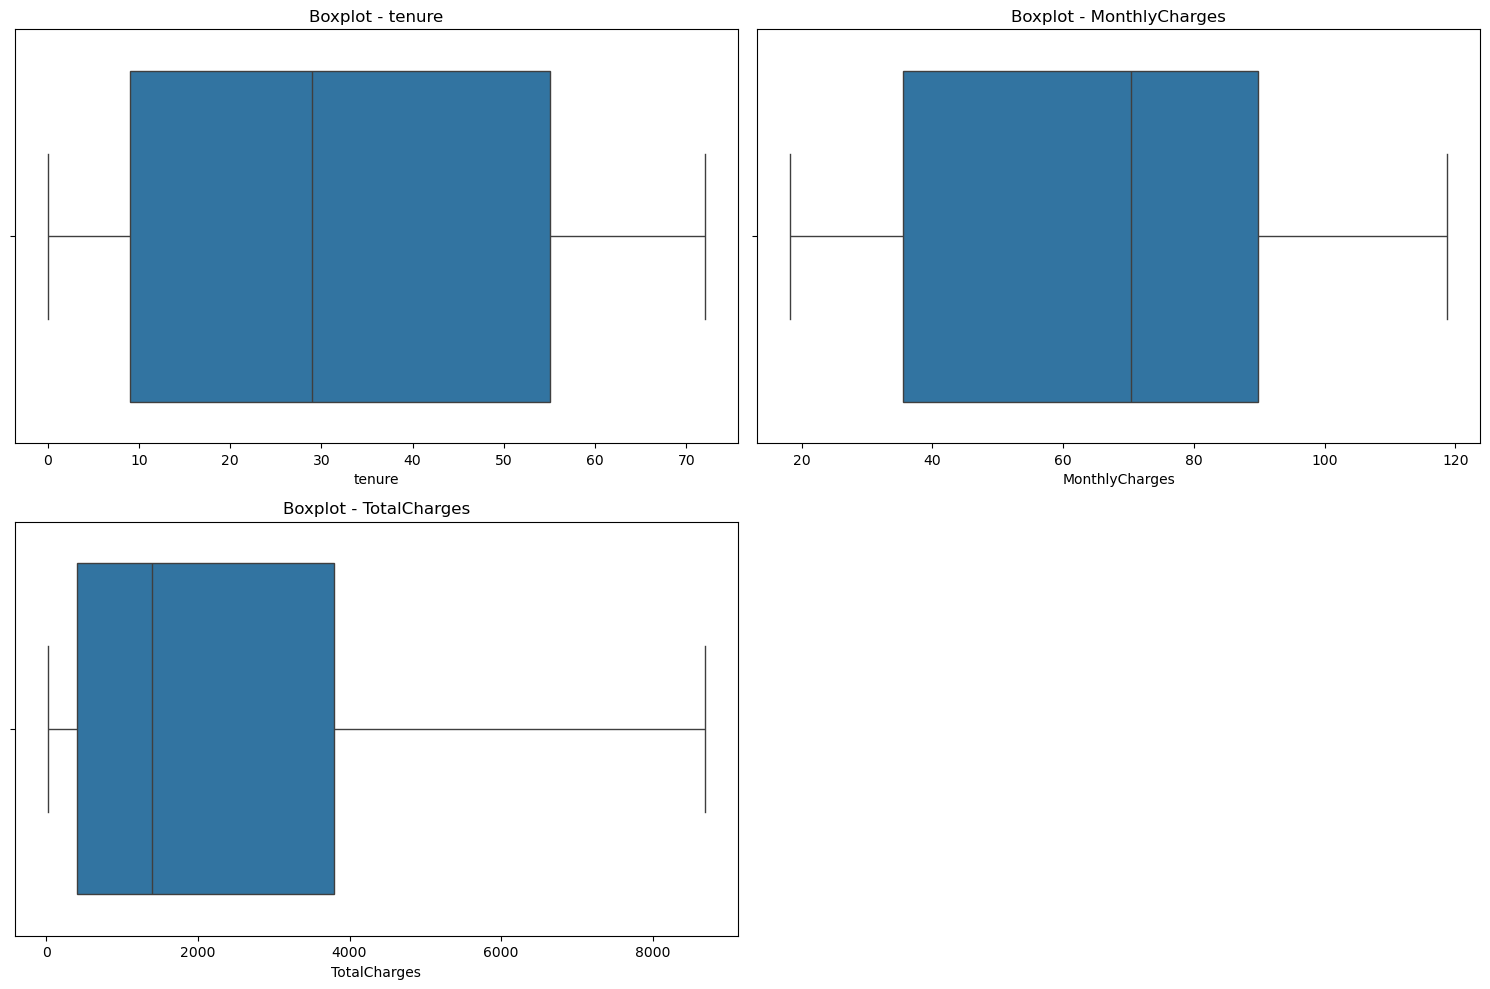

In [24]:
fig, axes = plt.subplots(2, 2, figsize = (15,10))
axes = axes.flatten()

for ax, col in zip(axes,cols_num):
    sns.boxplot(data=df_eda, x=col, ax=ax)
    ax.set_title(f"Boxplot - {col}")

for ax in axes[len(cols_num):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

* Distribuição das variáveis categóricas

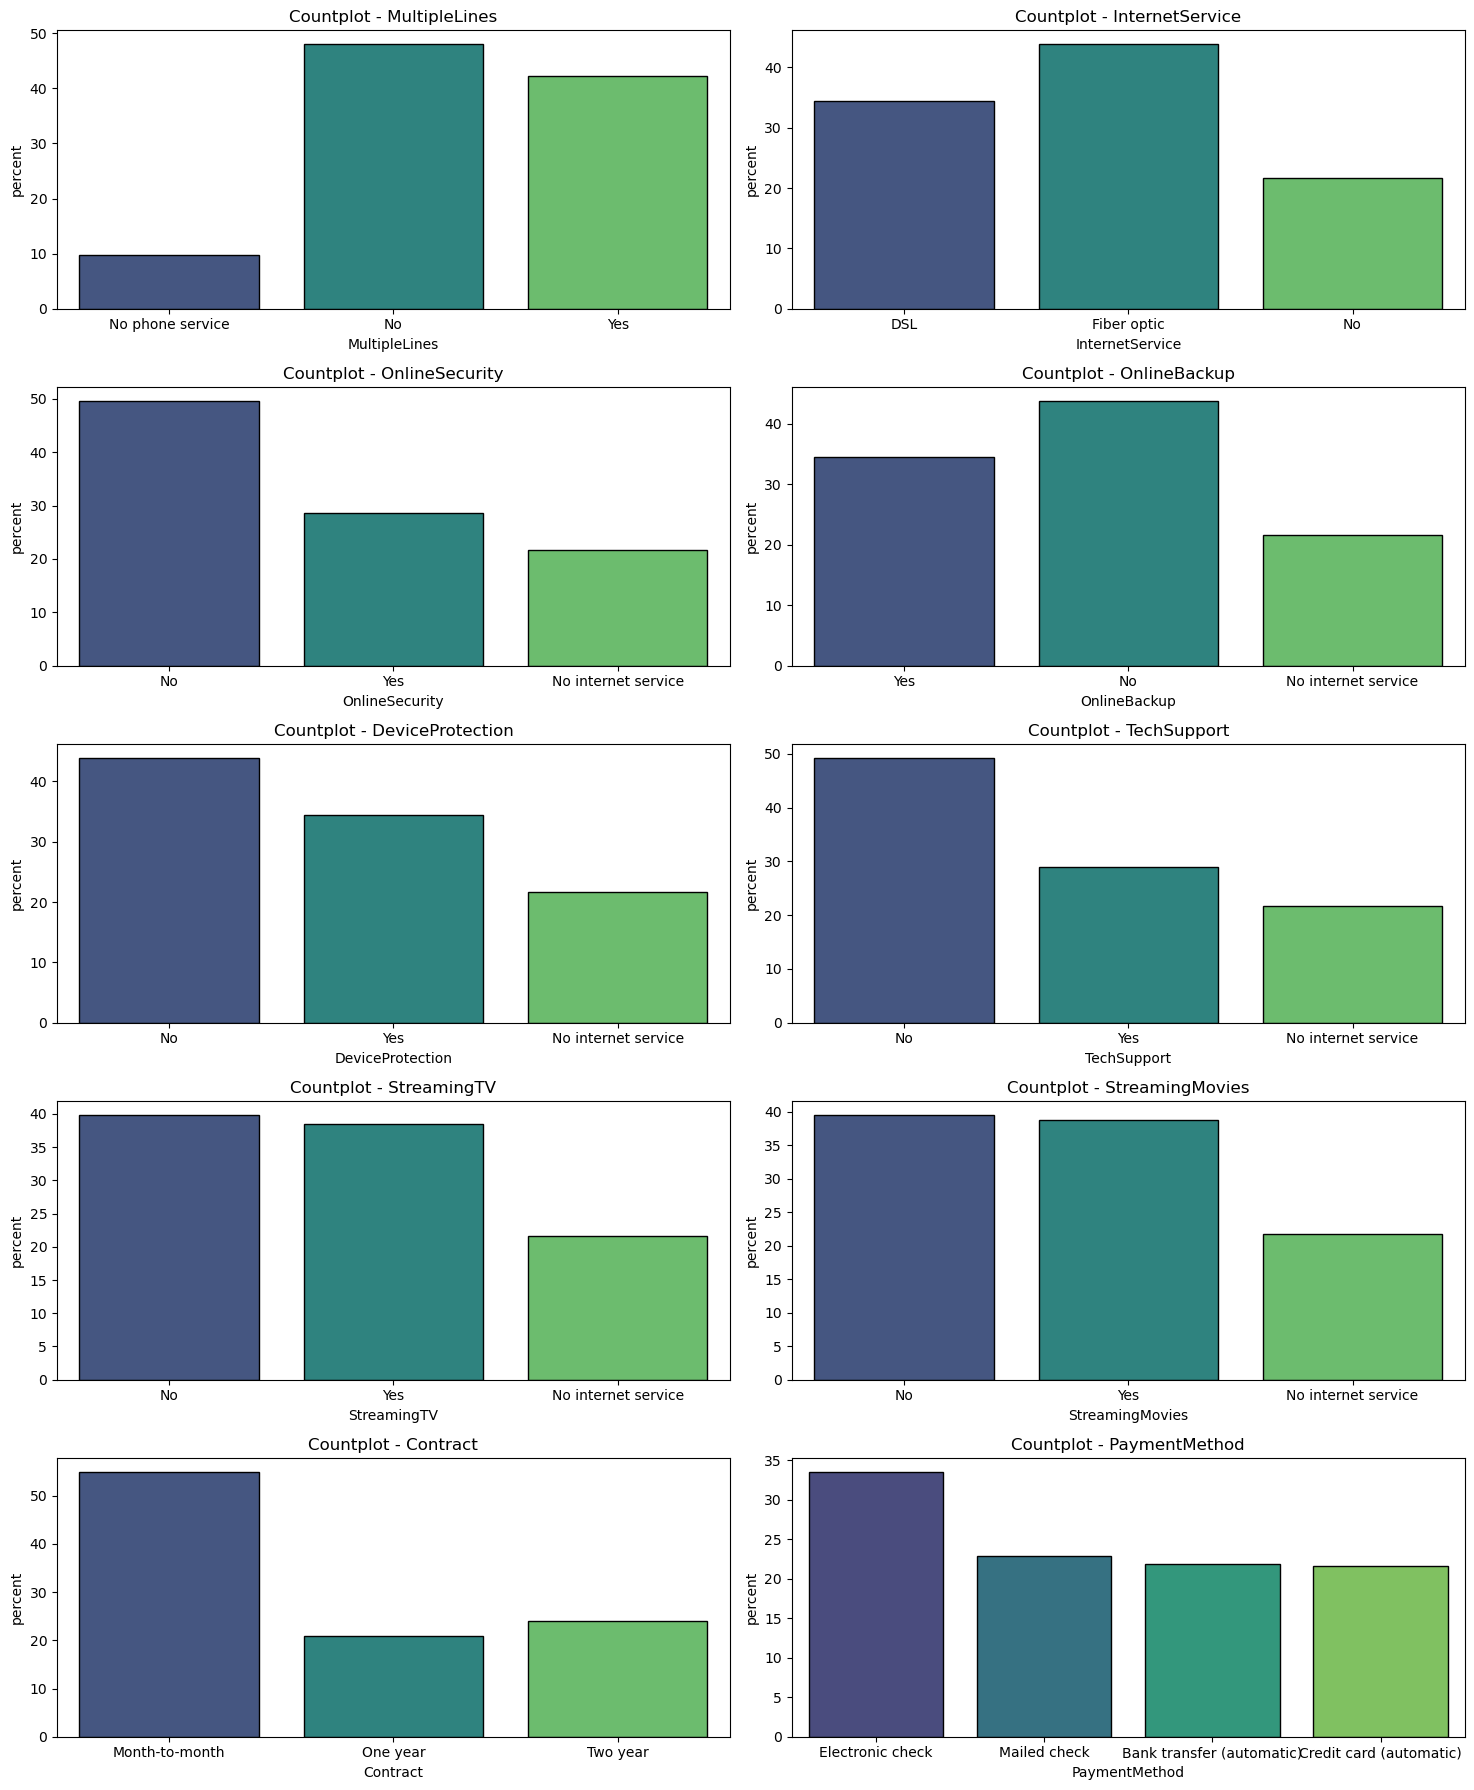

In [25]:
fig, axes = plt.subplots(5, 2, figsize = (15, 18))
axes = axes.flatten()

for ax, col in zip(axes, cols_cat):
        sns.countplot(data=df_eda, x=col, edgecolor="black", palette="viridis", ax=ax, stat="percent")
        ax.set_title(f"Countplot - {col}")

for ax in axes[len(cols_cat):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

* Distribuição das variáveis binárias

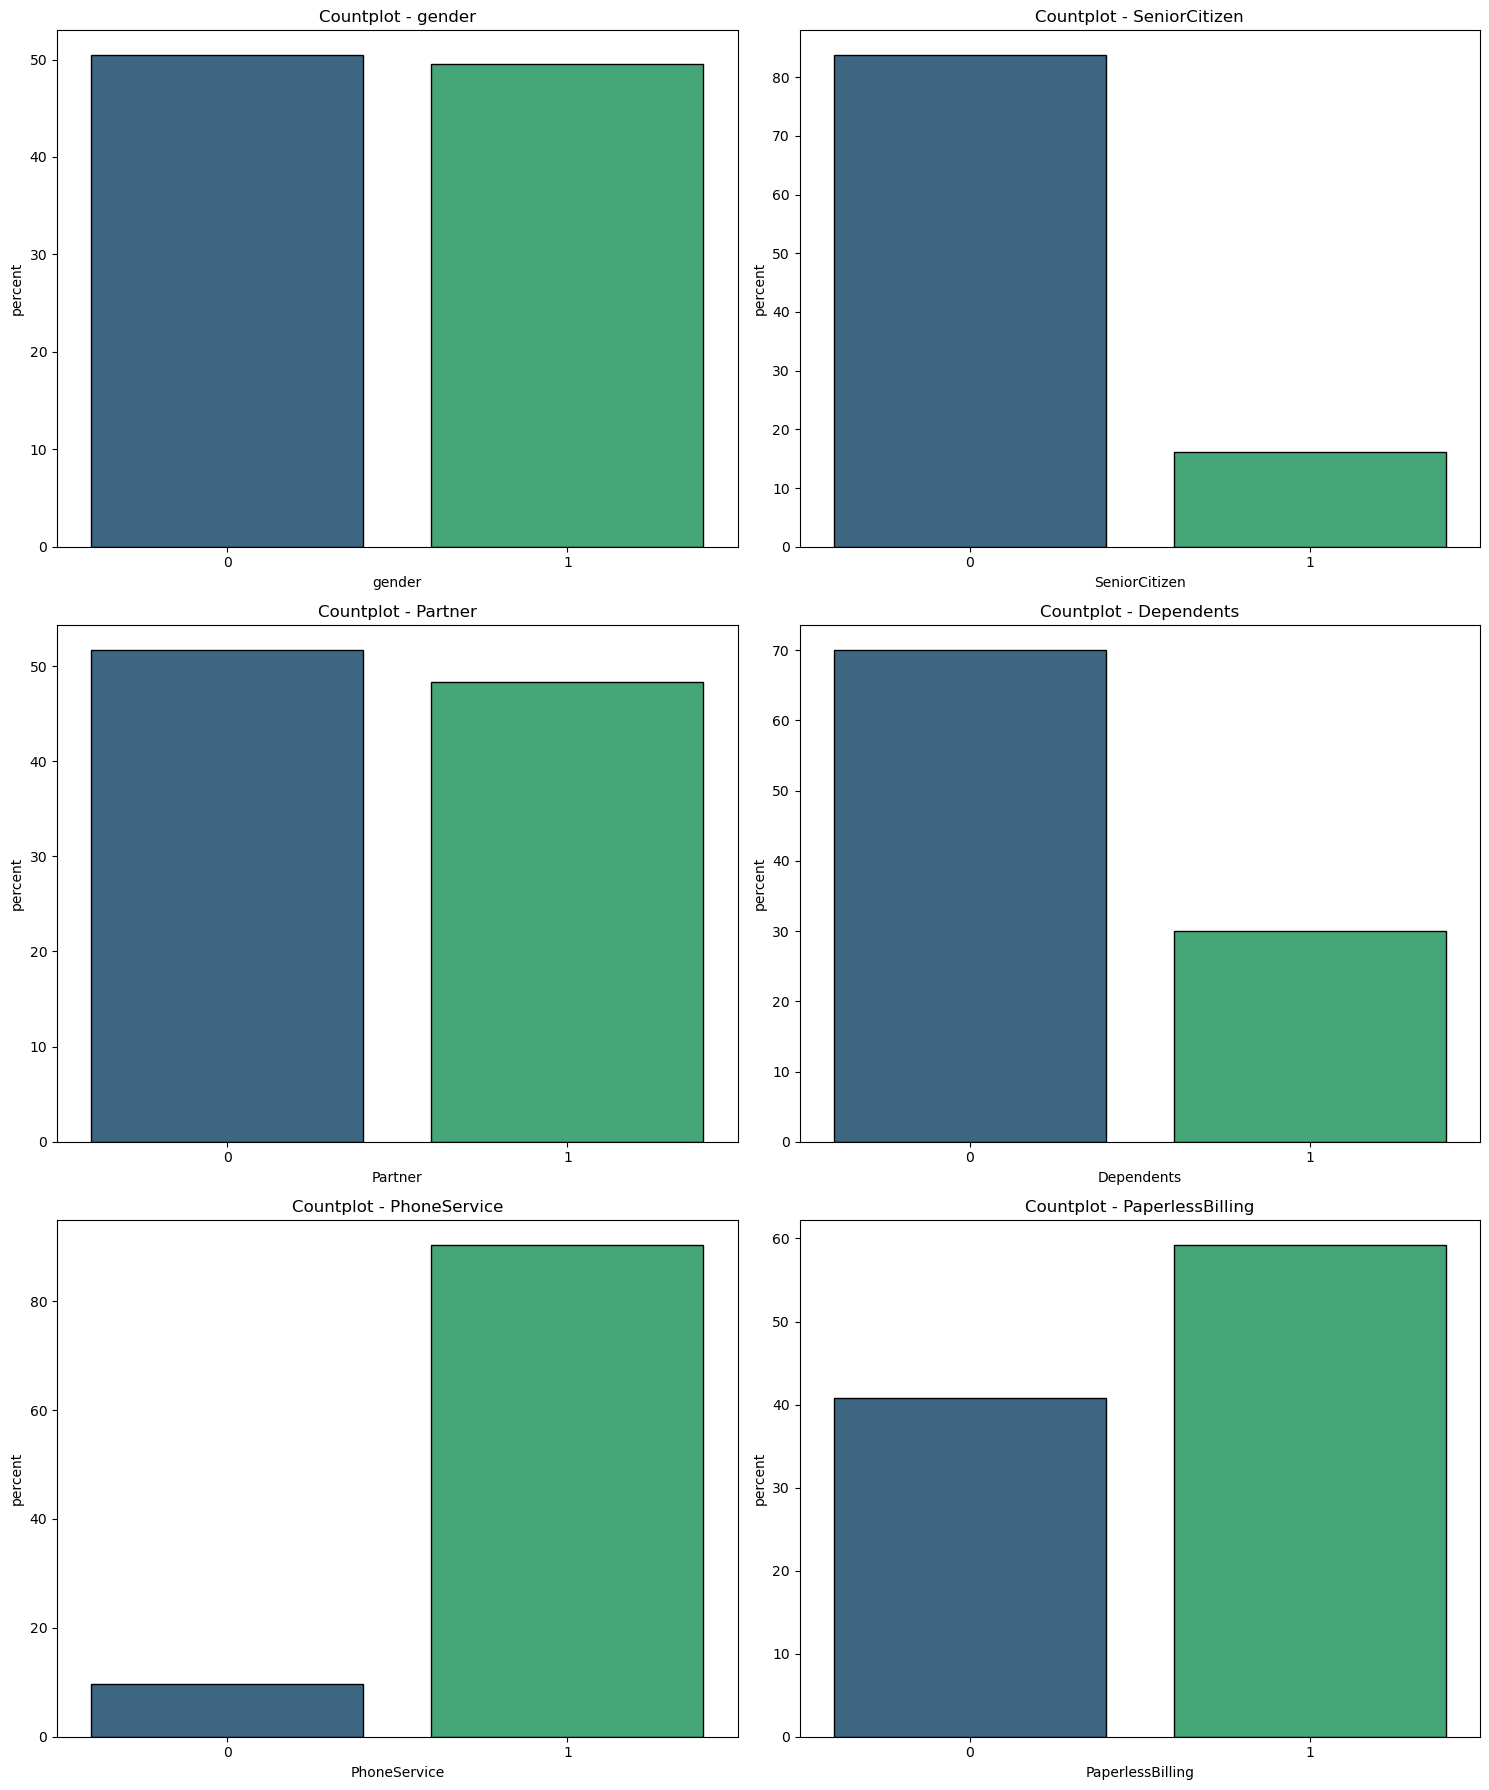

In [26]:
fig, axes = plt.subplots(3, 2, figsize = (15, 18))
axes = axes.flatten()

for ax, col in zip(axes, cols_bin):
        sns.countplot(data=df_eda, x=col, edgecolor="black", palette="viridis", ax=ax, stat="percent")
        ax.set_title(f"Countplot - {col}")

for ax in axes[len(cols_bin):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

* Relação da variável target com as variáveis numéricas

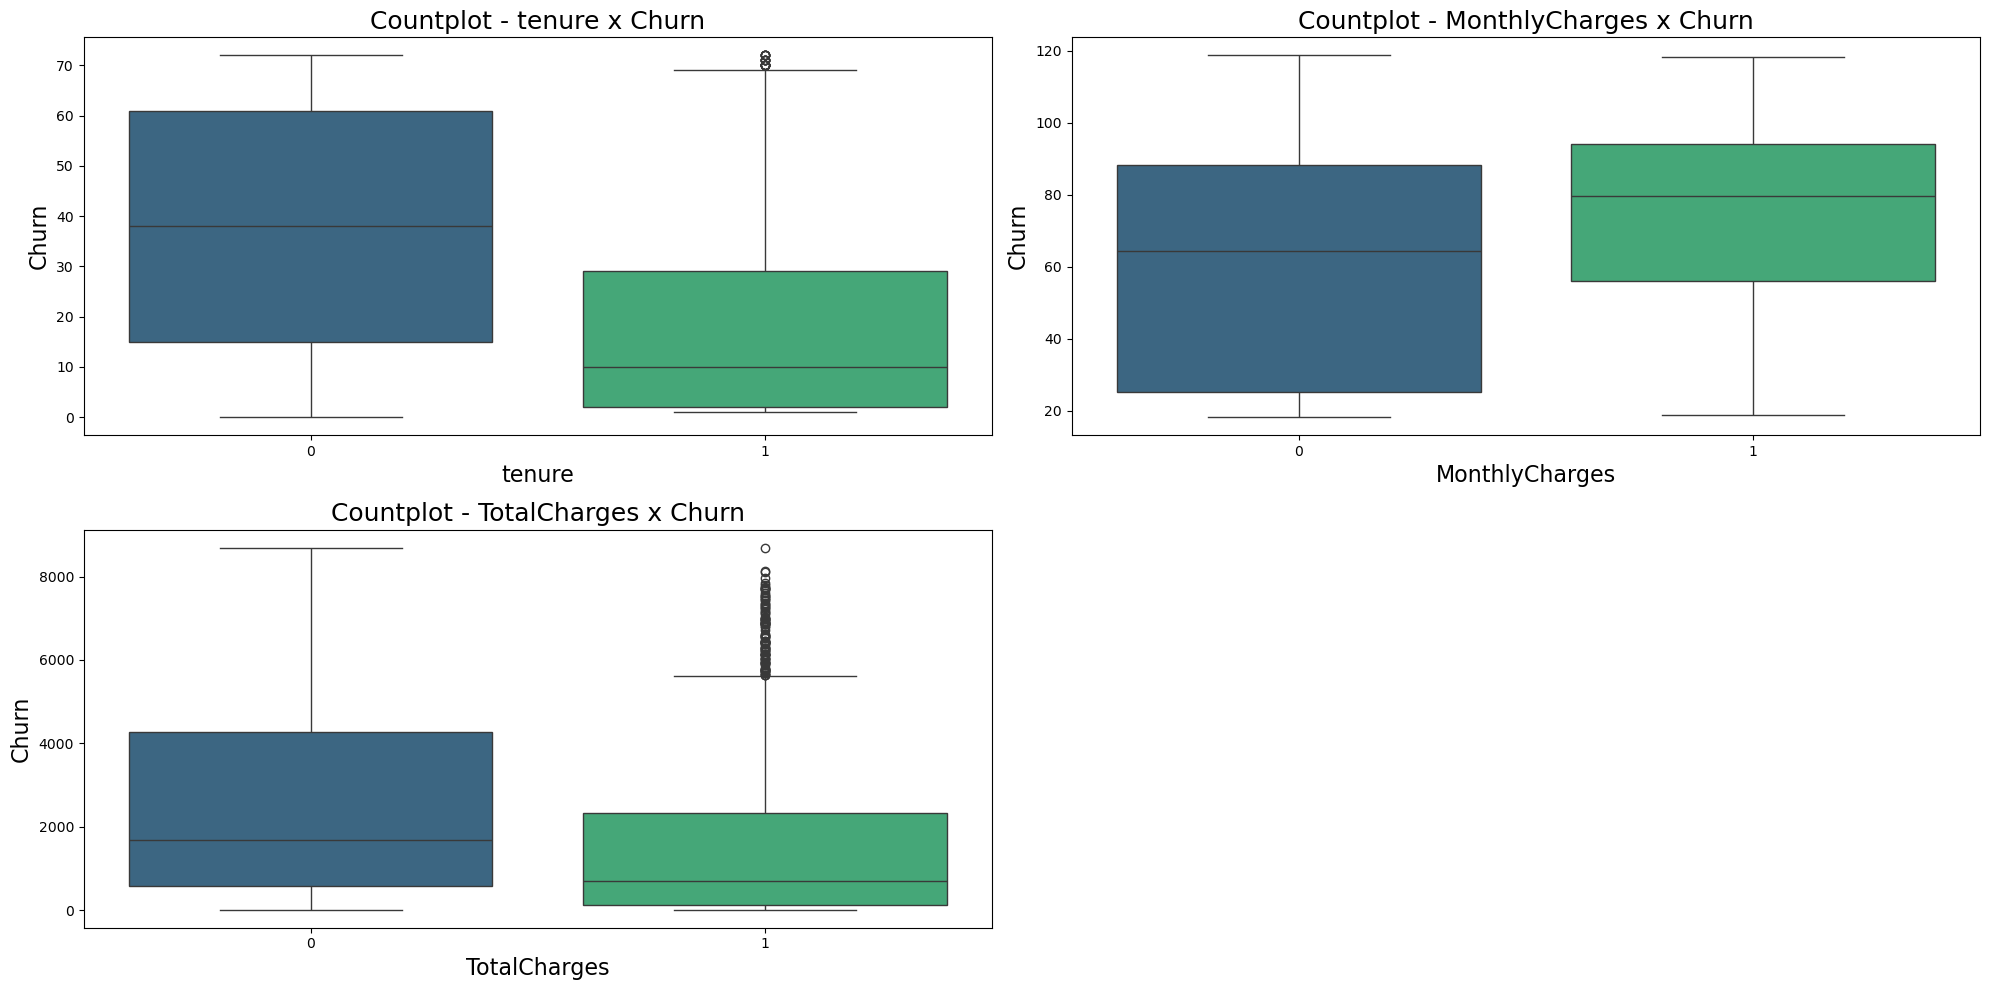

In [27]:
fig, axes = plt.subplots(2, 2, figsize = (20,10))
axes = axes.flatten()

for ax, col in zip(axes,cols_num):
    sns.boxplot(data=df_eda, x=target,
                y=col,
                palette="viridis",
                ax=ax)
    ax.set_title(f"Countplot - {col} x {target}", fontsize=18)
    ax.set_xlabel(col, fontsize=16)
    ax.set_ylabel(target, fontsize=16)
    
for ax in axes[len(cols_num):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

* Relação da variável target com as variáveis categóricas

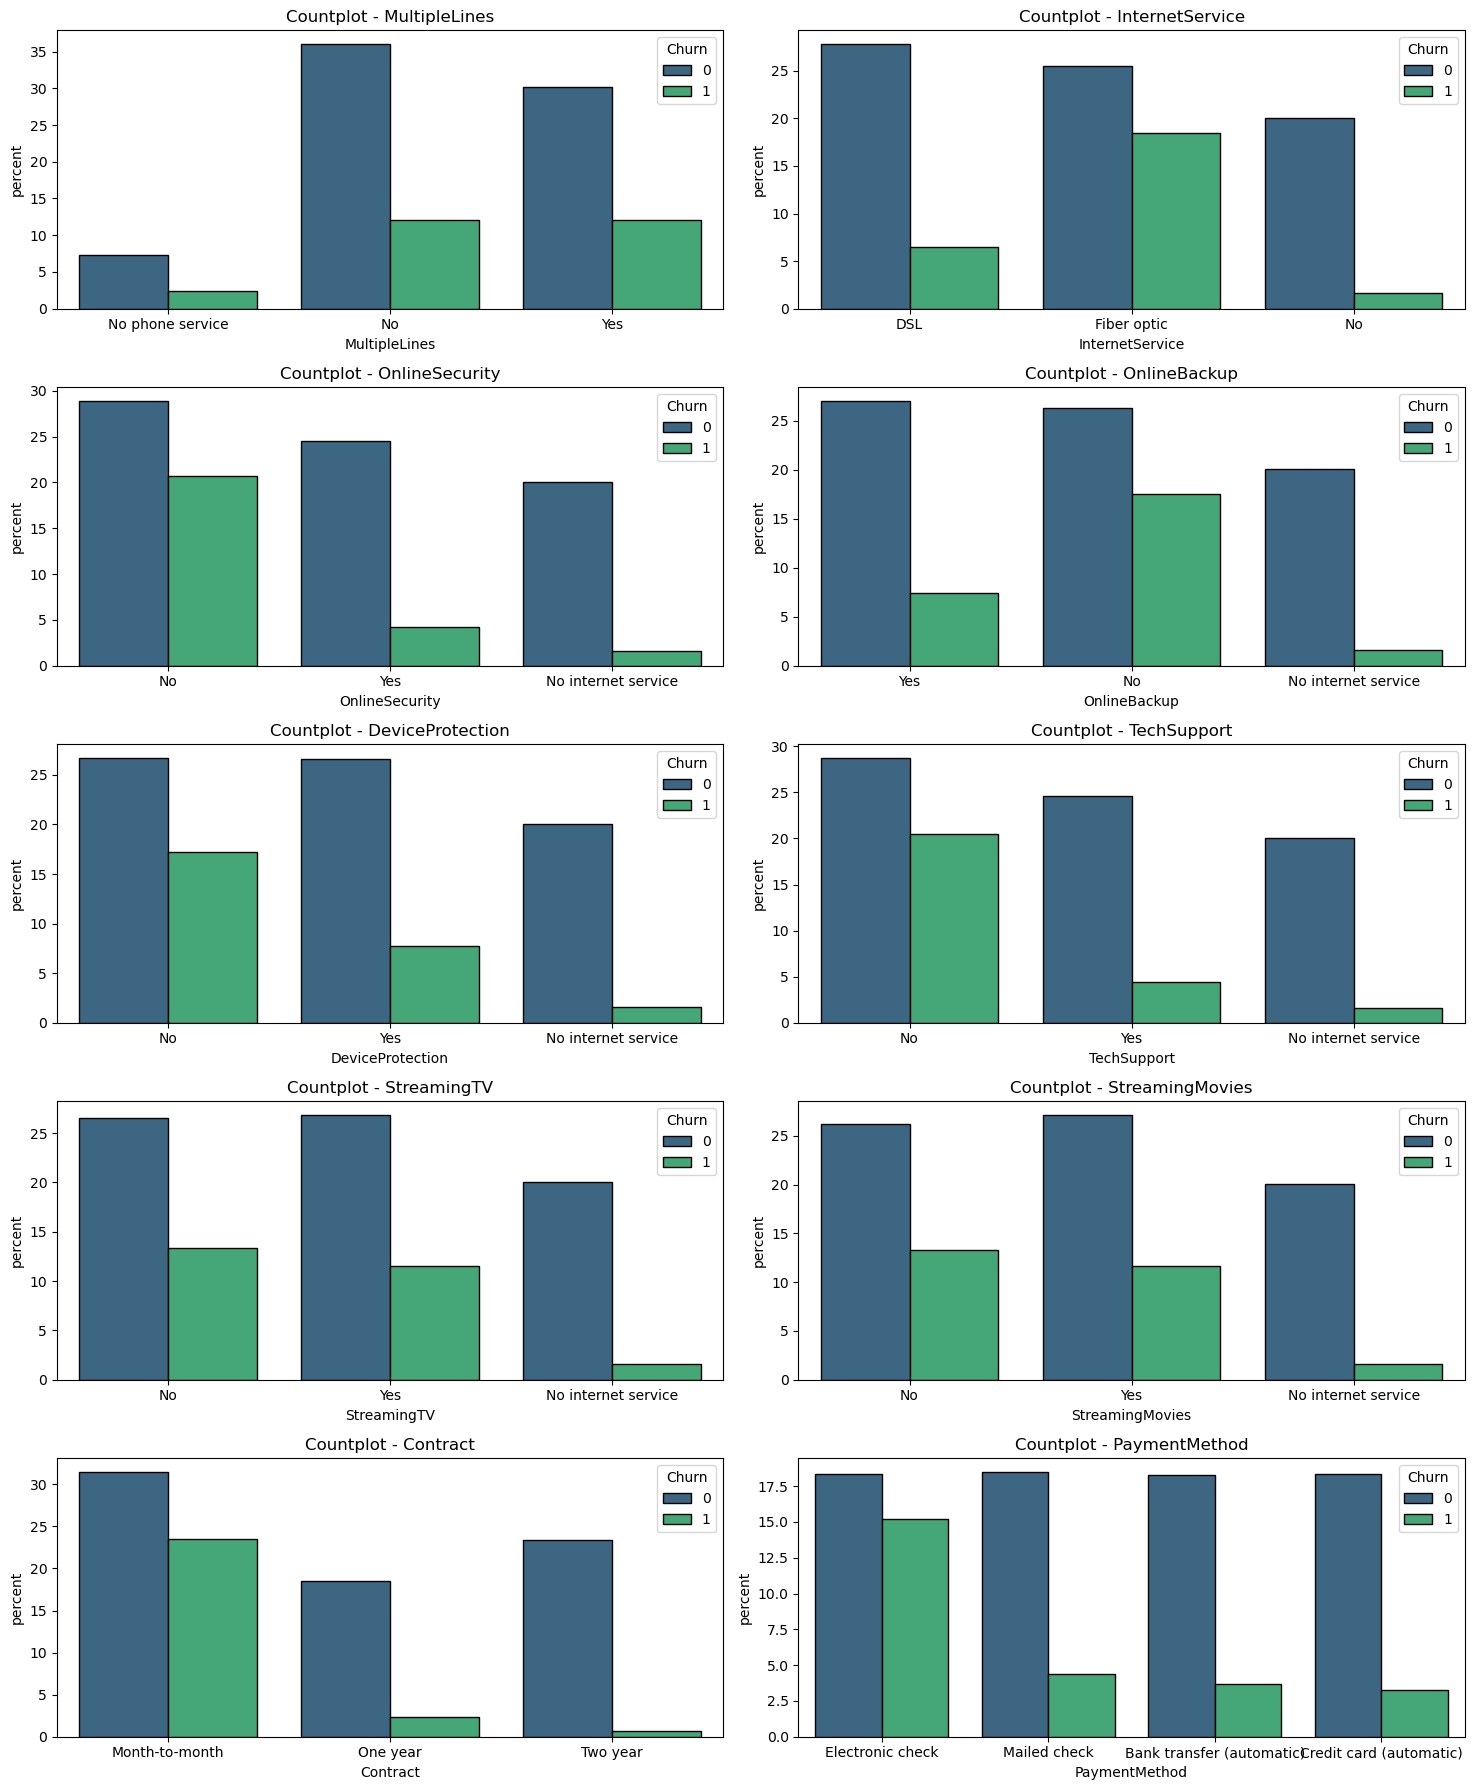

In [28]:
fig, axes = plt.subplots(5, 2, figsize = (15, 18))
axes = axes.flatten()

for ax, col in zip(axes, cols_cat):
        sns.countplot(data=df_eda, x=col, edgecolor="black", palette="viridis", hue=target, ax=ax, stat="percent")
        ax.set_title(f"Countplot - {col}")

for ax in axes[len(cols_cat):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

* Relação da variável target com as variáveis binárias

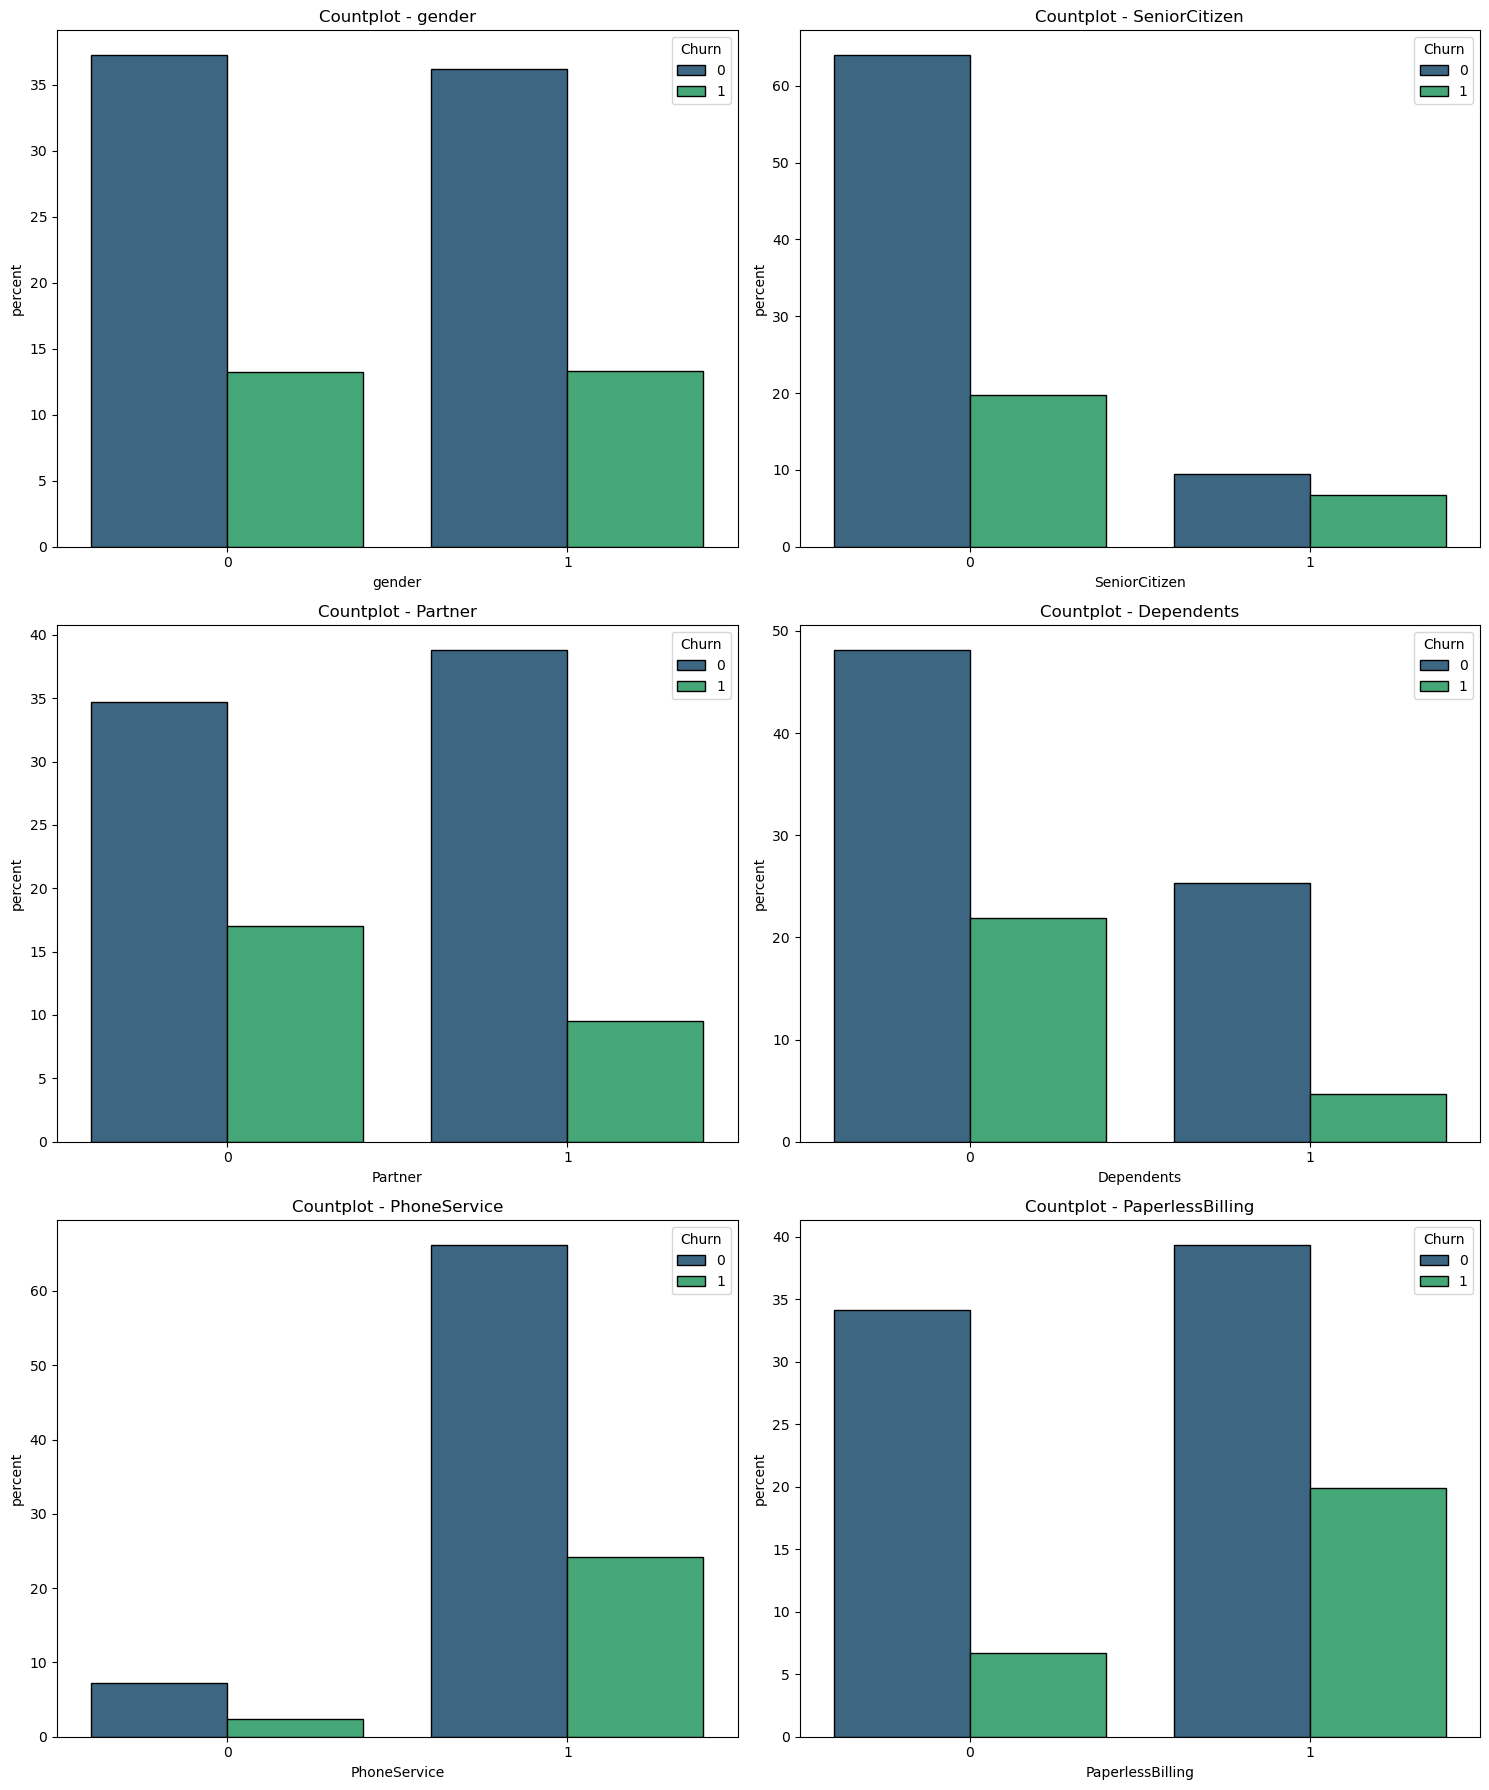

In [29]:
fig, axes = plt.subplots(3, 2, figsize = (15, 18))
axes = axes.flatten()

for ax, col in zip(axes, cols_bin):
        sns.countplot(data=df_eda, x=col, edgecolor="black", palette="viridis", hue=target, ax=ax, stat="percent")
        ax.set_title(f"Countplot - {col}")

for ax in axes[len(cols_bin):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

* Correlação

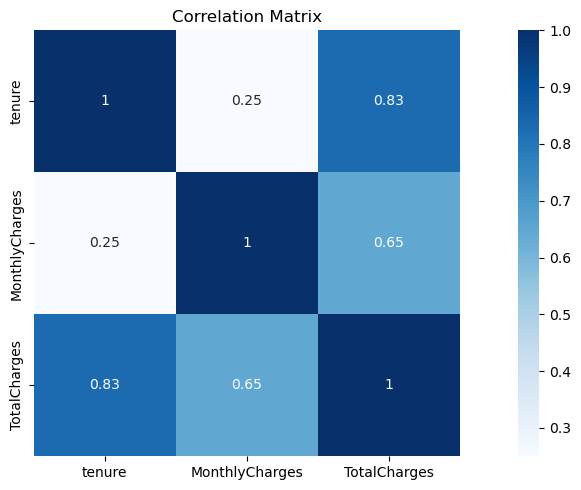

In [30]:
corr = df_eda[cols_num].corr().round(2)
plt.figure(figsize=(12,5))
sns.heatmap(corr, square=True, annot=True, cmap="Blues")

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

* Associação

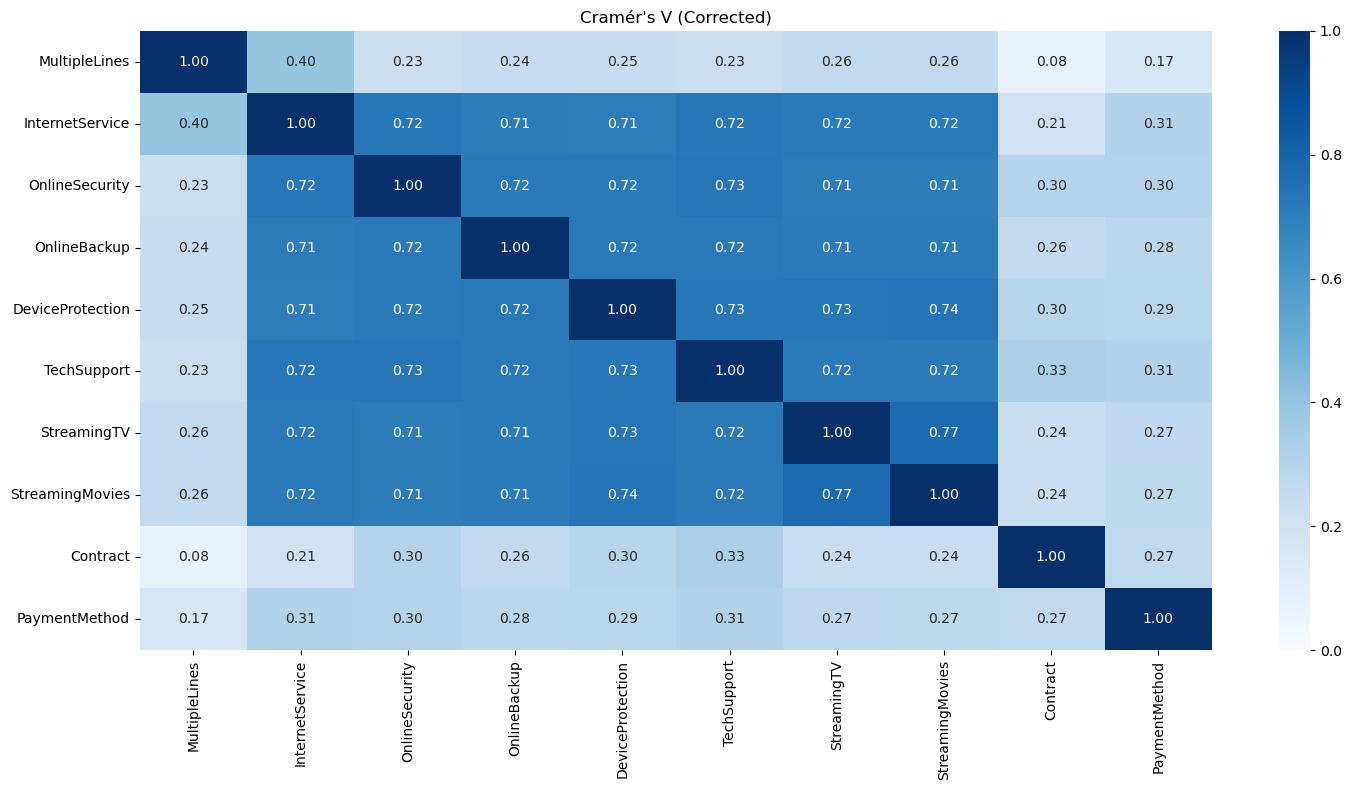

In [31]:
def cramers_v_corrected(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()

    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    phi2corr = max(0, phi2 - ((k - 1)*(r - 1))/(n - 1))
    rcorr = r - ((r - 1)**2)/(n - 1)
    kcorr = k - ((k - 1)**2)/(n - 1)

    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))


def compute_cramers_v_matrix(df, cols):
    mat = pd.DataFrame(index=cols, columns=cols, dtype=float)

    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            if j >= i:  # evita recomputação
                tab = pd.crosstab(df[c1], df[c2])
                val = cramers_v_corrected(tab.values)

                mat.loc[c1, c2] = val
                mat.loc[c2, c1] = val

    # Garantias numéricas
    mat = mat.astype(float)
    mat = (mat + mat.T) / 2
    np.fill_diagonal(mat.values, 1.0)

    return mat


def plot_cramers_heatmap(mat):
    plt.figure(figsize=(15, 8))
    sns.heatmap(mat, annot=True, cmap="Blues", vmin=0, vmax=1, fmt=".2f")
    plt.title("Cramér's V (Corrected)")
    plt.tight_layout()
    plt.show()

cramers_matrix = compute_cramers_v_matrix(df_eda, cols_cat)
plot_cramers_heatmap(cramers_matrix)

# Pré-processamento

* Dataset de pré-processamento

In [39]:
df_prep = df_eda.copy()

* Engenharia de features

In [40]:
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df_prep["num_services"] = df_prep[service_cols].apply(
    lambda row: sum(val == "Yes" for val in row),
    axis=1
)

* Tratamento de valores faltantes

In [41]:
cols_drop = ["customerID",
             "OnlineSecurity",
             "OnlineBackup",
             "DeviceProtection",
             "TechSupport",
             "StreamingTV",
             "StreamingMovies",
             "TotalCharges"
]

df_prep = df_prep.drop(columns=cols_drop)

* Pré-processador

In [42]:
target = 'Churn'

cols_bin = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

cols_cat = ['MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']

cols_num = ['tenure', 'MonthlyCharges', 'num_services']	

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num",
         StandardScaler(),
         cols_num
        ),
        ("bin",
         "passthrough",
         cols_bin
        ),
        ("cat",
         OneHotEncoder(handle_unknown="ignore", drop=None),
         cols_cat
        )
    ],
    remainder="drop"
)

* Separar X e Y

In [44]:
X = df_prep.drop(columns=["Churn"])
y = df_prep["Churn"]

* Dividir em treino e teste estratificado

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Treinamento e Avaliação de Modelos Base

* Criar avaliador universal

In [46]:
def evaluate_model(
    name,
    pipeline,
    X_test,
    y_test,
    threshold=0.5,
    plot_confusion=True,
    plot_pr_curve=True
):
    print(f"\n{'='*60}")
    print(f"MODEL: {name}")
    print(f"{'='*60}")

    y_proba = pipeline.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC:  {pr_auc:.4f}")

    y_pred = (y_proba >= threshold).astype(int)

    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    print("\nThreshold = 0.50")
    print(f"F1-score:  {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    if plot_confusion:
        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay.from_predictions(
            y_test,
            y_pred,
            ax=ax,
            cmap="Blues",
            values_format="d"
        )
        plt.title(f"Confusion Matrix – {name}")
        plt.tight_layout()
        plt.show()

    if plot_pr_curve:
        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)

        plt.figure(figsize=(6, 4))
        plt.plot(recall_vals, precision_vals)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision-Recall Curve – {name}")
        plt.tight_layout()
        plt.show()

    return {
        "Model": name,
        "ROC AUC": roc_auc,
        "PR AUC": pr_auc,
        "F1": f1,
        "Precision": precision,
        "Recall": recall,
        "y_proba": y_proba
    }

* Pipeline

In [47]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()


MODEL: Baseline – Most Frequent
ROC-AUC: 0.5000
PR-AUC:  0.2654

Threshold = 0.50
F1-score:  0.0000
Precision: 0.0000
Recall:    0.0000

Classification Report:
              precision    recall  f1-score   support

           0     0.7346    1.0000    0.8470      1035
           1     0.0000    0.0000    0.0000       374

    accuracy                         0.7346      1409
   macro avg     0.3673    0.5000    0.4235      1409
weighted avg     0.5396    0.7346    0.6222      1409



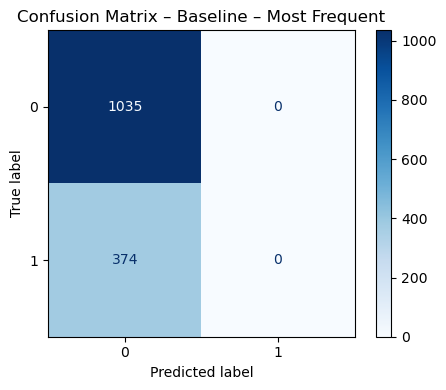

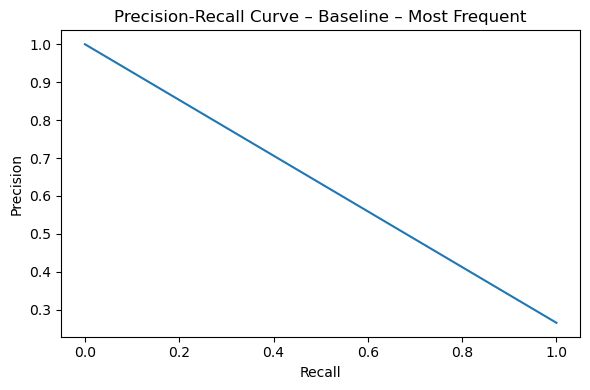


MODEL: Baseline – Stratified
ROC-AUC: 0.5163
PR-AUC:  0.2723

Threshold = 0.50
F1-score:  0.2903
Precision: 0.2891
Recall:    0.2914

Classification Report:
              precision    recall  f1-score   support

           0     0.7432    0.7411    0.7421      1035
           1     0.2891    0.2914    0.2903       374

    accuracy                         0.6217      1409
   macro avg     0.5162    0.5163    0.5162      1409
weighted avg     0.6227    0.6217    0.6222      1409



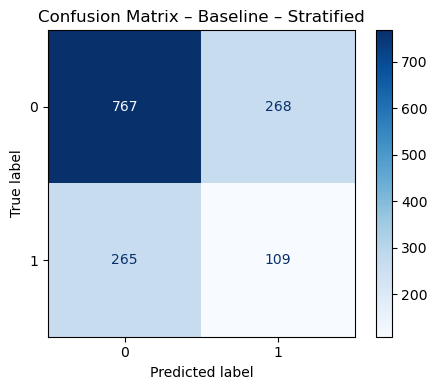

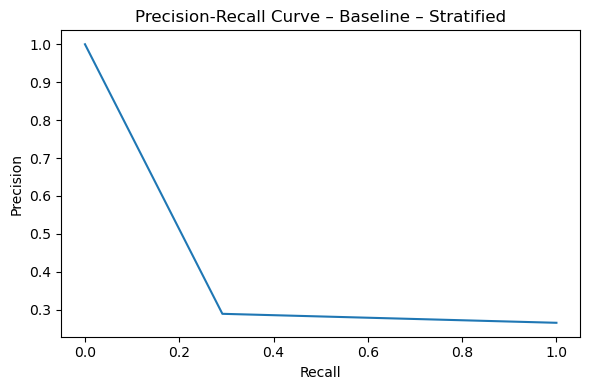


MODEL: Logistic Regression
ROC-AUC: 0.8388
PR-AUC:  0.6269

Threshold = 0.50
F1-score:  0.6105
Precision: 0.5035
Recall:    0.7754

Classification Report:
              precision    recall  f1-score   support

           0     0.8992    0.7237    0.8019      1035
           1     0.5035    0.7754    0.6105       374

    accuracy                         0.7374      1409
   macro avg     0.7013    0.7495    0.7062      1409
weighted avg     0.7941    0.7374    0.7511      1409



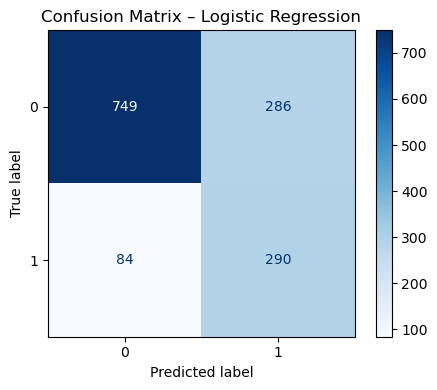

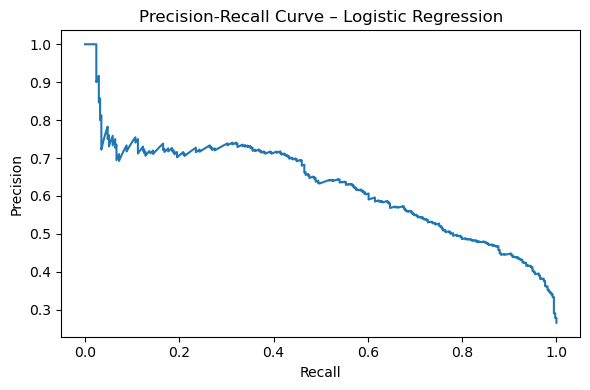


MODEL: Random Forest
ROC-AUC: 0.8131
PR-AUC:  0.5876

Threshold = 0.50
F1-score:  0.5510
Precision: 0.6058
Recall:    0.5053

Classification Report:
              precision    recall  f1-score   support

           0     0.8314    0.8812    0.8555      1035
           1     0.6058    0.5053    0.5510       374

    accuracy                         0.7814      1409
   macro avg     0.7186    0.6933    0.7033      1409
weighted avg     0.7715    0.7814    0.7747      1409



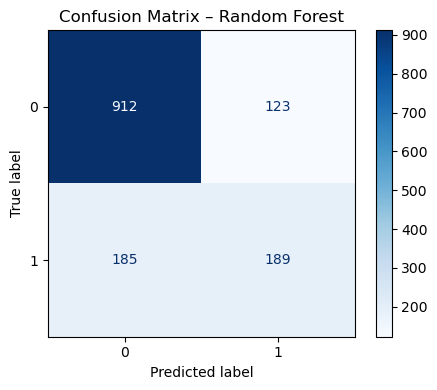

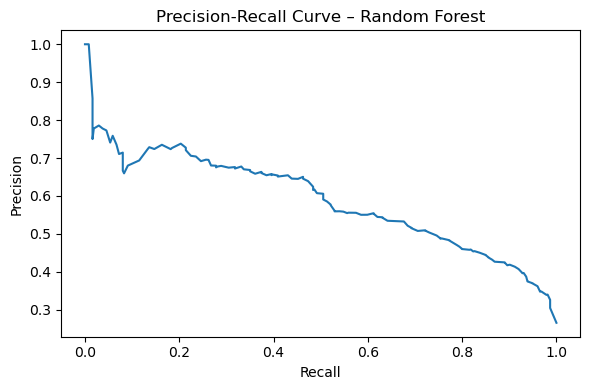


MODEL: XGBoost
ROC-AUC: 0.8257
PR-AUC:  0.6264

Threshold = 0.50
F1-score:  0.6007
Precision: 0.5273
Recall:    0.6979

Classification Report:
              precision    recall  f1-score   support

           0     0.8764    0.7739    0.8220      1035
           1     0.5273    0.6979    0.6007       374

    accuracy                         0.7537      1409
   macro avg     0.7018    0.7359    0.7113      1409
weighted avg     0.7837    0.7537    0.7632      1409



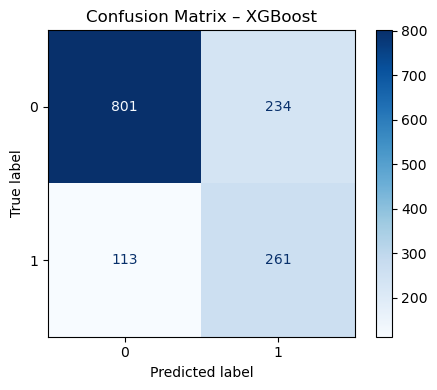

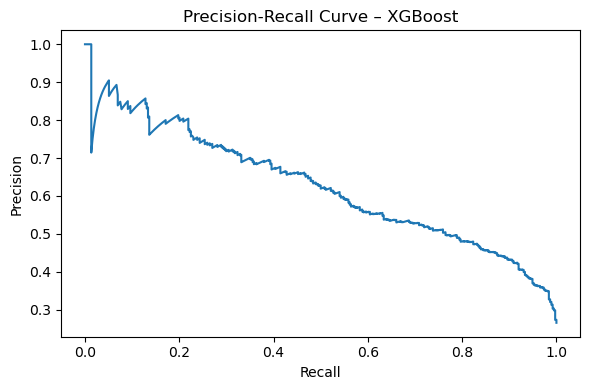

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001035 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 375
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328

MODEL: LightGBM
ROC-AUC: 0.8358
PR-AUC:  0.6414

Threshold = 0.50
F1-score:  0.6085
Precision: 0.5138
Recall:    0.7460

Classification Report:
              precision    recall  f1-score   support

           0     0.8903    0.7449    0.8112      1035
           1     0.5138    0.7460    0.6085       374

    accuracy                         0.7452      1409
   macro avg     0.7021    0.7455    0.7098      1409
weighted avg     0.7904    0.

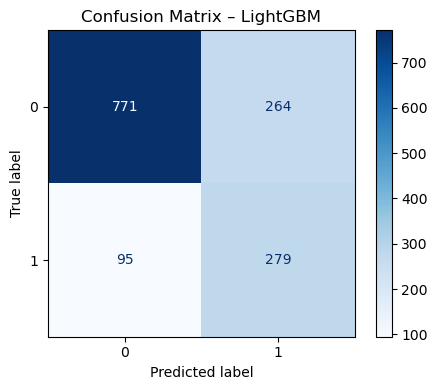

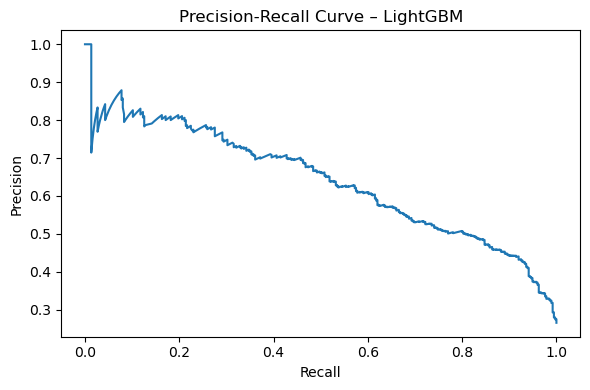

{'Model': 'LightGBM',
 'ROC AUC': 0.8357655842310574,
 'PR AUC': 0.6414353500359119,
 'F1': 0.608505997818975,
 'Precision': 0.5138121546961326,
 'Recall': 0.7459893048128342,
 'y_proba': array([0.00845818, 0.96699951, 0.20453361, ..., 0.21931321, 0.12278645,
        0.01087213], shape=(1409,))}

In [48]:
# Dummy – Most Frequent (lower bound)
dummy_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent", random_state=42))
])

dummy_pipe.fit(X_train, y_train)
evaluate_model("Baseline – Most Frequent", dummy_pipe, X_test, y_test)

dummy_strat = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DummyClassifier(strategy="stratified", random_state=42))
])

# Dummy – Stratified (baseline probabilístico)
dummy_strat.fit(X_train, y_train)
evaluate_model("Baseline – Stratified", dummy_strat, X_test, y_test)

# Regressão Logística
logreg_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logreg_pipe.fit(X_train, y_train)
evaluate_model("Logistic Regression", logreg_pipe, X_test, y_test)

# Random Forest
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)
evaluate_model("Random Forest", rf_pipe, X_test, y_test)

# XGBoost
xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        verbosity=0,
        n_jobs=-1
    ))
])

xgb_pipe.fit(X_train, y_train)
evaluate_model("XGBoost", xgb_pipe, X_test, y_test)

# LGBM
lgbm_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LGBMClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])

lgbm_pipe.fit(X_train, y_train)
evaluate_model("LightGBM", lgbm_pipe, X_test, y_test)

* Resultados

In [49]:
def get_metrics_triage(model, X_test, y_test, ks=(0.05, 0.1)):
    """
    Avaliação de modelos para churn (sem lift).

    - Métricas globais: AP, ROC-AUC
    - Métricas de ranking: Recall@K, Precision@K
    """

    # Probabilidades
    y_proba = model.predict_proba(X_test)[:, 1]

    # Métricas globais
    ap = average_precision_score(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    metrics = {
        "AP": ap,
        "ROC_AUC": auc
    }

    order = np.argsort(y_proba)[::-1]

    for k in ks:
        cutoff = int(len(y_test) * k)
        top_k_idx = order[:cutoff]

        recall_k = y_test.iloc[top_k_idx].sum() / y_test.sum()
        precision_k = y_test.iloc[top_k_idx].mean()

        metrics[f"Recall@{int(k*100)}%"] = recall_k
        metrics[f"Precision@{int(k*100)}%"] = precision_k

    return metrics

In [50]:
results = []

models = {
    "Dummy – Most Frequent": dummy_pipe,
    "Dummy – Stratified": dummy_strat,
    "Logistic Regression": logreg_pipe,
    "Random Forest": rf_pipe,
    "XGBoost": xgb_pipe,
    "LGBM": lgbm_pipe
}

for name, model in models.items():
    metrics = get_metrics_triage(model, X_test, y_test, ks=(0.05, 0.1))

    results.append([
        name,
        metrics["AP"],
        metrics["ROC_AUC"],
        metrics["Recall@5%"],
        metrics["Precision@5%"],
        metrics["Recall@10%"],
        metrics["Precision@10%"]
    ])

In [51]:
df_results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Avg Precision",
        "ROC-AUC",
        "Recall @ 5%",
        "Precision @ 5%",
        "Recall @ 10%",
        "Precision @ 10%"
    ]
)

In [52]:
df_results.sort_values("Avg Precision", ascending=False, inplace=True)
df_results

,Model,Avg Precision,ROC-AUC,Recall @ 5%,Precision @ 5%,Recall @ 10%,Precision @ 10%
5,LGBM,0.641435,0.835766,0.149733,0.800000,0.286096,0.764286
2,Logistic Regression,0.626859,0.838839,0.133690,0.714286,0.270053,0.721429
4,XGBoost,0.626418,0.825738,0.144385,0.771429,0.272727,0.728571
3,Random Forest,0.587551,0.813093,0.136364,0.728571,0.259358,0.692857
1,Dummy – Stratified,0.272340,0.516253,0.072193,0.385714,0.114973,0.307143
0,Dummy – Most Frequent,0.265436,0.500000,0.042781,0.228571,0.080214,0.214286


# Modelos Promissores

* LGBM

In [ ]:
lgbm_param_grid = {
    "model__n_estimators": [200, 500, 1000],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__num_leaves": [31, 63],
    "model__max_depth": [-1, 5, 10],
    "model__min_child_samples": [20, 50],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

lgbm_pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LGBMClassifier(
            objective="binary",
            scale_pos_weight=scale_pos_weight,  
            random_state=42,
            n_jobs=-1
        ))
    ],
    memory=memory
)

grid_lgbm = GridSearchCV(
    estimator=lgbm_pipe,
    param_grid=lgbm_param_grid,
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
    refit=True
)

print("Starting Search LightGBM...")
grid_lgbm.fit(X_train, y_train)

Starting Search LightGBM...


* Regressão Logística

In [ ]:
logreg_param_grid = {
    "model__penalty": ["l1", "l2", "elasticnet"],
    "model__C": [0.01, 0.05, 0.1, 0.5, 1.0],
    "model__solver": ["saga"],  # único compatível com elasticnet
    "model__l1_ratio": [0.1, 0.5, 0.9],  # usado apenas se elasticnet
    "model__class_weight": ["balanced"]
}

logreg_pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ],
    memory=memory
)

grid_logreg = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=logreg_param_grid,
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
    refit=True
)

print("Starting Grid Search Logistic Regression...")
grid_logreg.fit(X_train, y_train)

* Comparação dos modelos promissores

In [77]:
models_optimized = {
    "LGBM (Tuned)": grid_lgbm.best_estimator_,
    "Logistic Regression (Tuned)": grid_logreg.best_estimator_
}

results_opt = []

for name, model in models_optimized.items():
    metrics = get_metrics_triage(model, X_test, y_test)

    results_opt.append([
        name,
        metrics["AP"],
        metrics["ROC_AUC"],
        metrics["Recall@5%"],
        metrics["Recall@10%"],
    ])

df_results_opt = pd.DataFrame(
    results_opt,
    columns=[
        "Modelo",
        "Avg Precision (AP)",
        "ROC-AUC",
        "Recall @ 5%",
        "Recall @ 10%",
    ]
)

df_results_opt.sort_values("Avg Precision (AP)", ascending=False, inplace=True)
df_results_opt

,Modelo,Avg Precision (AP),ROC-AUC,Recall @ 5%,Recall @ 10%
1,Logistic Regression (Tuned),0.627072,0.838898,0.133690,0.270053
0,LGBM (Tuned),0.626733,0.834529,0.147059,0.272727


# Análise de Erros e Interpretação do Modelo Final

* Análise de Thresholds Clínicos (Ponto de Corte)

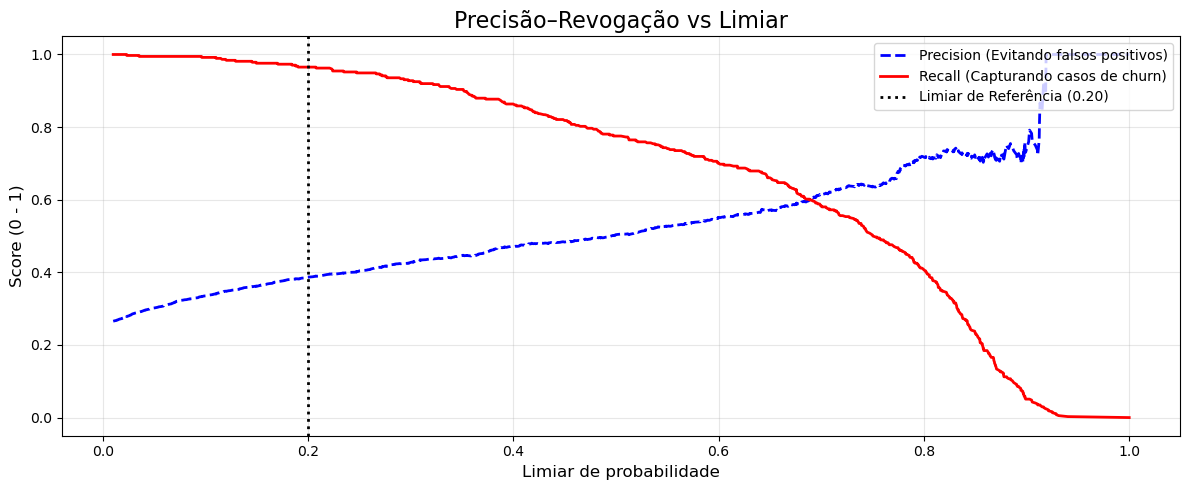

In [78]:
# -----------------------------------------------------------
# 1. Obter probabilidades para a classe positiva (Churn)
# -----------------------------------------------------------
y_proba = grid_logreg.best_estimator_.predict_proba(X_test)[:, 1]

# -----------------------------------------------------------
# 2. Calcular precision e recall
# -----------------------------------------------------------
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# thresholds tem tamanho n-1, precision e recall tamanho n
thresholds_plot = np.append(thresholds, 1.0)  # para alinhar os comprimentos (opcional)

plt.figure(figsize=(12, 5))

# Plot Precision e Recall vs Threshold
plt.plot(thresholds_plot, precision, 'b--', label='Precision (Evitando falsos positivos)', linewidth=2)
plt.plot(thresholds_plot, recall, 'r-', label='Recall (Capturando casos de churn)', linewidth=2)

# -----------------------------------------------------------
# 3. Marcar um threshold de referência para análise de trade-off
# -----------------------------------------------------------
threshold_candidato = 0.2  # exemplo operacional
plt.axvline(threshold_candidato, color='black', linestyle=':', 
            label=f'Limiar de Referência ({threshold_candidato:.2f})', linewidth=2)

# -----------------------------------------------------------
# 4. Ajustes de estética
# -----------------------------------------------------------
plt.title('Precisão–Revogação vs Limiar', fontsize=16)
plt.xlabel('Limiar de probabilidade',fontsize=12)
plt.ylabel('Score (0 - 1)',fontsize=12)
plt.grid(alpha=0.3)
plt.legend(loc='upper right',fontsize=10)
plt.tight_layout()

# plt.savefig("Curvas Precisão-Recall.svg", format="svg")

plt.show()

* Probabilidades preditas e calibração

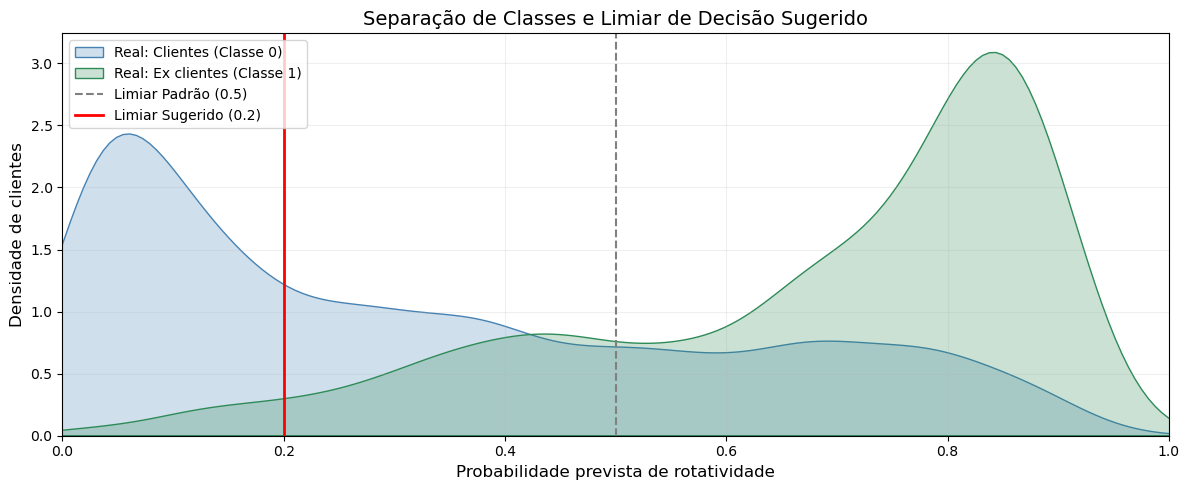

In [80]:
plt.figure(figsize=(12, 5))

# 1. Distribuição para clientes (Classe 0)
sns.kdeplot(
    y_proba[y_test == 0],
    fill=True,
    color="steelblue",
    label="Real: Clientes (Classe 0)",
    bw_adjust=0.7
)

# 2. Distribuição para ex clientes (Classe 1)
sns.kdeplot(
    y_proba[y_test == 1],
    fill=True,
    color="seagreen",
    label="Real: Ex clientes (Classe 1)",
    bw_adjust=0.7
)

# 3. Linhas de Threshold para Comparação
plt.axvline(0.5, color="gray", linestyle="--", label="Limiar Padrão (0.5)")
plt.axvline(0.2, color="red", linestyle="-", linewidth=2, label="Limiar Sugerido (0.2)")

# 4. Formatação Técnica
plt.title("Separação de Classes e Limiar de Decisão Sugerido", fontsize=14)
plt.xlabel("Probabilidade prevista de rotatividade", fontsize=12)
plt.ylabel("Densidade de clientes", fontsize=12)
plt.xlim(0, 1)
plt.legend(loc='best')
plt.grid(alpha=0.2)
plt.tight_layout()

# plt.savefig("Separação de Classes.svg", format="svg")

plt.show()

* Calibração

Brier Score (Rotatividade): 0.1693


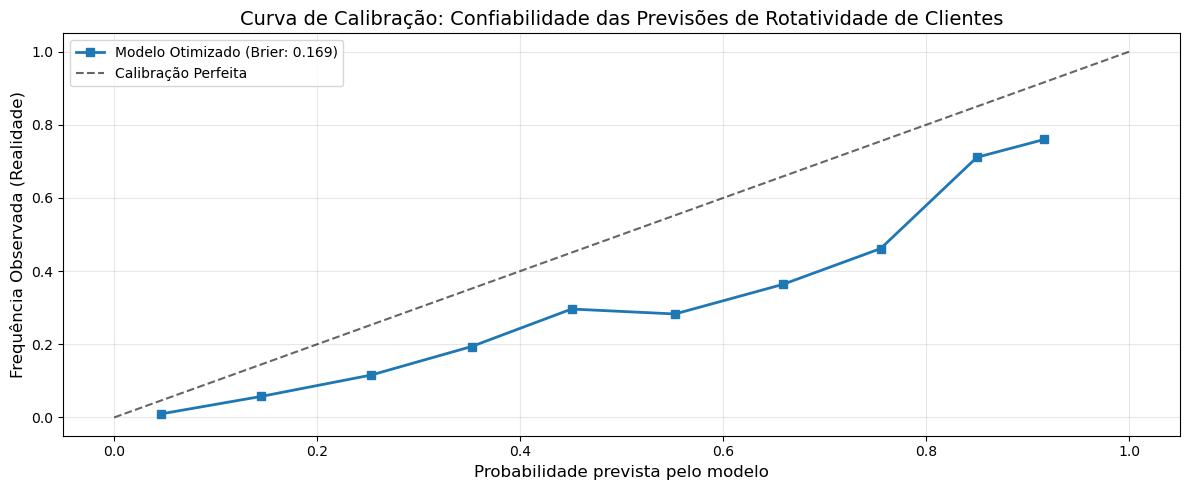

In [83]:
# 1. Calcular a Curva de Calibração
# n_bins=10 divide as probabilidades em fatias de 10%
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

# 2. Calcular Brier Score (Quanto menor, melhor a calibração)
brier = brier_score_loss(y_test, y_proba)
print(f"Brier Score (Rotatividade): {brier:.4f}")

# 3. Plotagem
plt.figure(figsize=(12, 5))
plt.plot(prob_pred, prob_true, marker='s', linewidth=2, label=f'Modelo Otimizado (Brier: {brier:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.6, label='Calibração Perfeita')

plt.title('Curva de Calibração: Confiabilidade das Previsões de Rotatividade de Clientes', fontsize=14)
plt.xlabel('Probabilidade prevista pelo modelo', fontsize=12)
plt.ylabel('Frequência Observada (Realidade)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

# plt.savefig("Brier Score.svg", format="svg")

plt.show()

* ROC-AUC

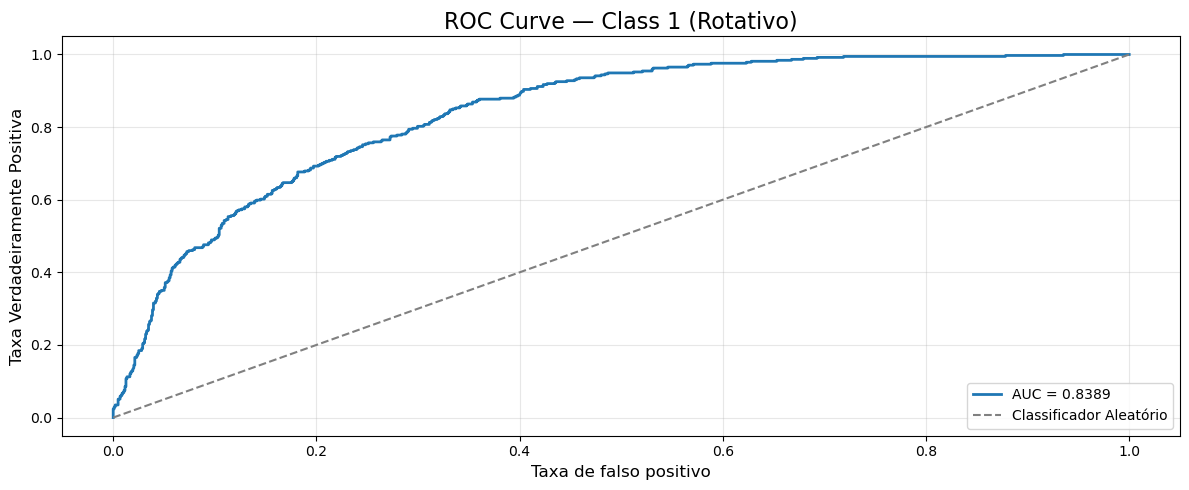

In [84]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# AUC
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(12, 5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Classificador Aleatório")

plt.title("ROC Curve — Class 1 (Rotativo)", fontsize=16)
plt.xlabel("Taxa de falso positivo", fontsize=12)
plt.ylabel("Taxa Verdadeiramente Positiva", fontsize=12)
plt.legend(loc="lower right",fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

* Matriz de confusão

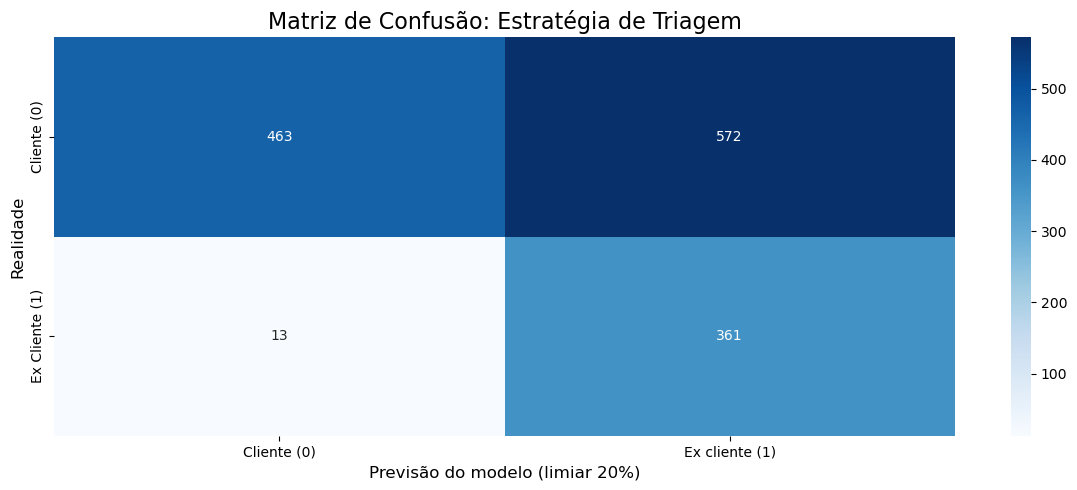

Sensibilidade (Revogação): 96.52%
Casos de rotatividade identificados: 361
Casos de rotatividade perdidos (Falsos Negativos): 13


In [86]:
# 1. Aplicar o Threshold Clínico de 0.20 (definido nas análises anteriores)
# Isso transforma probabilidades em classes (0 ou 1)
y_pred_clinico = (y_proba >= 0.20).astype(int)

# 2. Gerar a Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_clinico)

# 3. Plotagem
plt.figure(figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=['Cliente (0)', 'Ex cliente (1)'], 
            yticklabels=['Cliente (0)', 'Ex Cliente (1)'])

plt.title("Matriz de Confusão: Estratégia de Triagem", fontsize=16)
plt.xlabel("Previsão do modelo (limiar 20%)", fontsize=12)
plt.ylabel("Realidade", fontsize=12)
plt.tight_layout()

# plt.savefig("Matriz de Confusão.svg", format="svg")

plt.show()

# 4. Extração de Métricas de Negócio
tn, fp, fn, tp = cm.ravel()
recall = tp / (tp + fn)
print(f"Sensibilidade (Revogação): {recall:.2%}")
print(f"Casos de rotatividade identificados: {tp}")
print(f"Casos de rotatividade perdidos (Falsos Negativos): {fn}")

* Coeficientes e log-odds

In [93]:
feature_names = preprocessor_step.get_feature_names_out()
coef = classifier_model.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient_scaled": coef
})


num_mask = coef_df["Feature"].str.startswith("num__")
bin_mask = coef_df["Feature"].str.startswith("bin__")
cat_mask = coef_df["Feature"].str.startswith("cat__")


scaler = preprocessor_step.named_transformers_["num"]
scales = scaler.scale_


coef_df["Coefficient_original"] = coef_df["Coefficient_scaled"]

coef_df.loc[num_mask, "Coefficient_original"] = (
    coef_df.loc[num_mask, "Coefficient_scaled"].values / scales
)


coef_df["Odds Ratio"] = np.exp(coef_df["Coefficient_original"])


coef_df["Feature"] = (
    coef_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("bin__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

coef_df = coef_df.sort_values(by="Odds Ratio", ascending=False)

coef_df.head()

,Feature,Coefficient_scaled,Coefficient_original,Odds Ratio
14,InternetService_No,0.751192,0.751192,2.119525
15,Contract_Month-to-month,0.738374,0.738374,2.092530
10,MultipleLines_No phone service,0.709081,0.709081,2.032123
20,PaymentMethod_Electronic check,0.387157,0.387157,1.472788
8,PaperlessBilling,0.364915,0.364915,1.440391
